# CollisionSplatting quickstart

Collision checking and motion planning **directly on a standard 3D Gaussian Splatting scene** -- no mesh, no SDF,
no retraining. This notebook

1. downloads a raw 3DGS export of a *generated* world (a public [Marble](https://marble.worldlabs.ai) sample),
2. checks collisions and shows how the conservatism factor $n_\sigma$ inflates uncertain splats,
3. plans with the batched GPU RRT and renders the result with [gsplat](https://github.com/nerfstudio-project/gsplat).

Requirements: `pip install -e ".[examples]"` and a CUDA GPU.

In [1]:
import numpy as np, torch, matplotlib.pyplot as plt
from collisionsplatting import GaussianScene, CollisionChecker, BatchedRRT, path_length
from collisionsplatting.datasets import download_marble_sample

## 1. Load a raw 3DGS export
Any INRIA-format `.ply` works (3DGS, 2DGS, gsplat, nerfstudio, Marble, ...). `drop_floaters()` removes splats that are
both nearly transparent and large (haze and floaters, paper Sec. II-C).

In [2]:
scene = GaussianScene.from_ply(download_marble_sample("rustic_kitchen_with_natural_light")).drop_floaters()
lo, hi = scene.bounds(quantile=0.03)
print(f"{len(scene):,} splats | bounds {lo.round(2)} .. {hi.round(2)} | Marble scenes are y-down (OpenCV)")

499,840 splats | bounds [-1.15 -1.2  -1.47] .. [1.49 1.06 3.55] | Marble scenes are y-down (OpenCV)


## 2. Collision queries and the conservatism knob
Each splat is treated as an uncertain point obstacle. For a robot ellipsoid we compute the scaling distance $s^2$
(< 1 means inside), propagate the splat covariance to its standard deviation $\sigma$, and use
$\tilde s^2 = \max(0, s^2 - n_\sigma\,\sigma)$. Larger $n_\sigma$ means more caution around large, uncertain splats.

Warp 1.11.1 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/mim-server/.cache/warp/1.11.1
Module collisionsplatting.kernels ac8e2b3 load on device 'cuda:0' took 0.81 ms  (cached)


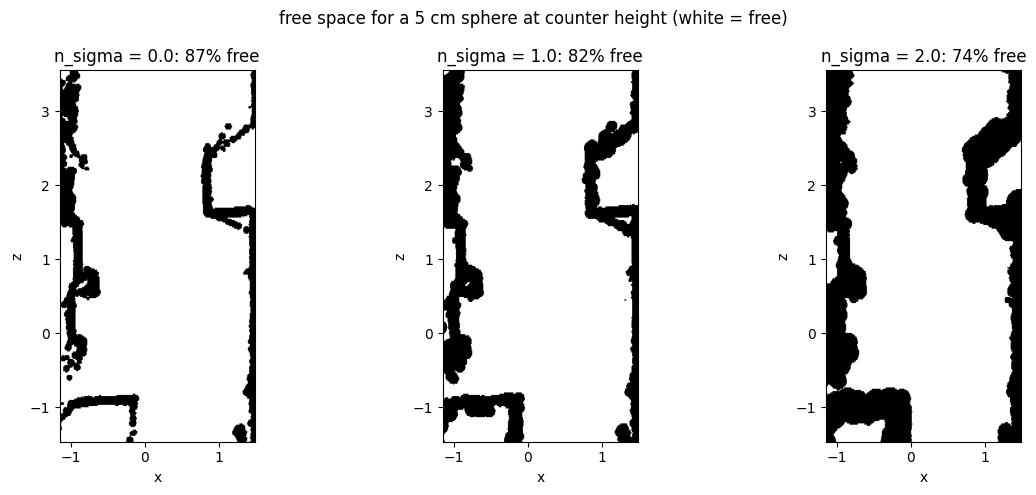

In [3]:
xs, zs = np.linspace(lo[0], hi[0], 300), np.linspace(lo[2], hi[2], 300)
X, Z = np.meshgrid(xs, zs)
pts = torch.tensor(np.stack([X.ravel(), np.zeros(X.size), Z.ravel()], 1), dtype=torch.float32, device="cuda")
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
for ax, ns in zip(axs, (0.0, 1.0, 2.0)):
    free = CollisionChecker(scene, n_sigma=ns).is_free(pts, radius=0.05).reshape(X.shape).cpu().numpy()
    ax.imshow(free, cmap="gray", origin="lower", extent=[xs[0], xs[-1], zs[0], zs[-1]])
    ax.set_title(f"n_sigma = {ns}: {100 * free.mean():.0f}% free"); ax.set_xlabel("x"); ax.set_ylabel("z")
fig.suptitle("free space for a 5 cm sphere at counter height (white = free)"); plt.tight_layout()

## 3. Plan with the batched GPU RRT
The RRT adds up to 32 branches per iteration and checks every new edge in a single kernel launch.

In [4]:
checker = CollisionChecker(scene, n_sigma=1.0)
rrt = BatchedRRT(checker, lower=lo, upper=hi, body_axes=0.08, step_size=0.08, seed=1)
res = rrt.plan(start=[-0.62, -0.04, -0.25], goal=[-0.28, 0.72, 2.38])
path = rrt.postprocess(res.path)            # shortcut + collision-checked smoothing
print(f"solved in {res.time:.2f} s, {res.iterations} iterations, {len(res.nodes):,} nodes; "
      f"path {res.length:.2f} -> {path_length(path):.2f} after smoothing")

solved in 0.31 s, 58 iterations, 1,546 nodes; path 3.93 -> 3.39 after smoothing


## 4. Render the plan inside the splats
Trees, paths and robots are drawn as extra Gaussians, so the scene handles occlusion.

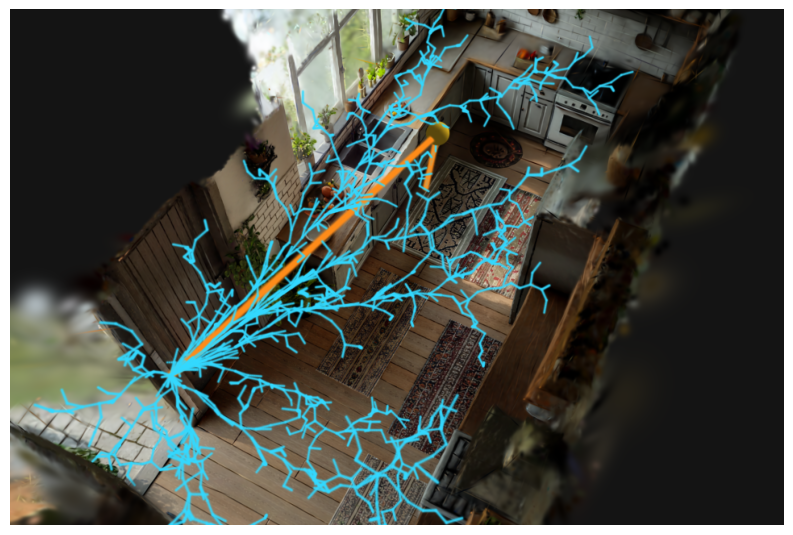

In [5]:
from collisionsplatting.render import render, look_at, intrinsics, merge, tree_splats, polyline_splats, sphere_splats
no_ceiling = scene.select(scene.means[:, 1] > lo[1] + 0.25 * (hi[1] - lo[1]))
view = merge([no_ceiling, tree_splats(res.nodes, res.parents, width=0.004), polyline_splats(path, width=0.012),
              sphere_splats(path[len(path) // 2], 0.08)])
c = 0.5 * (lo + hi)
img = render(view, look_at(c + np.array([1.2, -3.5, -2.2]), c, up=(0, -1, 0)), intrinsics(960, 640, 60), 960, 640)
plt.figure(figsize=(10, 6.7)); plt.imshow(img.cpu().numpy()); plt.axis("off");

## Next steps
* `examples/03_mppi_navigation.py` -- receding-horizon MPPI with the CollisionSplatting cost.
* `examples/04_conservatism.py` -- sweep $n_\sigma$ on your own scene.
* `examples/05_flexiv_image_goal_mppi.py` -- image goals (DINOv2) + collisions for a 7-DoF arm.
* `examples/06_benchmark.py` -- throughput and memory.